In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

1. Завантажуємо датасет з Google Drive

In [ ]:
#dataset_house_apartment.csv
file_id = "1_4iuDOm1WAvV7yPGiKbgOO4YxTpBvE4K"
url = f"https://drive.google.com/uc?id={file_id}"

house = pd.read_csv(url)
#Копіюємо оригінальний датасет, щоб подальші маніпуляції проводити у новому датасеті
house_clean = house.copy()

Розглянемо структуру оригінальної таблиці:

In [ ]:
#Перевіряємо структуру оригінальної таблиці
print("="*50)
print (f"Розмір оригінальної таблиці: {house.shape}")
print("="*50)
print("Колонки оригінальної таблиці:")
print("="*50)
print(house.columns)
print("="*50)
print("З наступними типами:")
print(house.dtypes)
print("="*50)
print("Огляд структури оригінальної таблиці:")
print("="*50)
house.info()
print("="*50)
print("Перші 5 рядків оригінальної таблиці:")
print("="*50)
house.head()

Розмір оригінальної таблиці: (52077, 20)
Колонки оригінальної таблиці:
Index(['locality', 'type_of_property', 'subtype_of_property', 'price',
       'type_of_sale', 'number_of_rooms', 'house_area',
       'fully_equipped_kitchen', 'furnished', 'open_fire', 'terrace',
       'terrace_area', 'garden', 'garden_area', 'surface_of_the_land',
       'surface_of_the_plot_of_land', 'number_of_facades', 'swimming_pool',
       'state_of_the_building', 'construction_year'],
      dtype='object')
З наступними типами:
locality                         int64
type_of_property                object
subtype_of_property             object
price                           object
type_of_sale                    object
number_of_rooms                float64
house_area                     float64
fully_equipped_kitchen           int64
furnished                      float64
open_fire                        int64
terrace                          int64
terrace_area                   float64
garden              

,locality,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,house_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,surface_of_the_plot_of_land,number_of_facades,swimming_pool,state_of_the_building,construction_year
0,1050,house,house,340000,for sale,6.0,203.0,1,NaN,0,1,NaN,0,NaN,95.0,NaN,2.0,0,to be done up,1901.0
1,1880,house,villa,525000,for sale,6.0,250.0,1,NaN,0,1,40.0,1,430.0,826.0,NaN,4.0,0,as new,1992.0
2,4900,house,exceptional property,550000,for sale,11.0,475.0,1,NaN,0,1,NaN,1,1400.0,1543.0,NaN,4.0,0,good,1853.0
3,7912,house,villa,550000,for sale,4.0,325.0,1,NaN,0,1,125.0,1,2333.0,3570.0,NaN,4.0,0,good,1918.0
4,6032,house,house,550000,for sale,5.0,400.0,1,NaN,0,1,80.0,1,500.0,616.0,NaN,3.0,0,as new,1977.0


Аналізуємо пропуски у колонках:

In [ ]:
missing_info = pd.DataFrame({
    'Кількість пропусків': house.isna().sum(),
    'Частка пропусків (%)': (house.isna().mean()*100).round(2)
})

missing_info = missing_info.sort_values(by = 'Частка пропусків (%)', ascending = False)
print(missing_info)

                             Кількість пропусків  Частка пропусків (%)
surface_of_the_plot_of_land                52077                100.00
furnished                                  52077                100.00
garden_area                                43624                 83.77
terrace_area                               34559                 66.36
surface_of_the_land                        22724                 43.64
construction_year                          21369                 41.03
number_of_facades                          13650                 26.21
state_of_the_building                      13586                 26.09
house_area                                  8632                 16.58
subtype_of_property                            0                  0.00
type_of_property                               0                  0.00
locality                                       0                  0.00
price                                          0                  0.00
terrac

Видаляємо стовпці, у яких велика частка пропусків (>70 %)

In [ ]:
threshold = 0.7

cols_to_drop = missing_info[missing_info['Частка пропусків (%)']>threshold*100].index
print(f"Колонки, які підлягають видаленню: {list(cols_to_drop)}")
#Видаляємо ці колонки
house_clean = house_clean.drop(columns=cols_to_drop)

print(f"Залишилося колонок: {len(house_clean.columns)}")

Колонки, які підлягають видаленню: ['surface_of_the_plot_of_land', 'furnished', 'garden_area']
Залишилося колонок: 17


Стовпчик **price** має тип object, перетворюємо на число:

In [ ]:
house_clean['price'] = pd.to_numeric(house_clean['price'], errors='coerce')
#Перевірка результату
print(f"Тип данних у стовпці 'price' оригінальної таблиці: {house['price'].dtypes}")
print(f"Тип данних у стовпці 'price' після перетворення: {house_clean['price'].dtypes}")
print("="*50)

print(f'Кількість пропусків price після перетворення: {house_clean['price'].isna().sum()}')
#Видаляємо пропуски
before = len(house_clean)
house_clean = house_clean.dropna(subset=['price'])
after = len(house_clean)
print(f'Видалено {before - after} рядків')


Тип данних у стовпці 'price' оригінальної таблиці: object
Тип данних у стовпці 'price' після перетворення: float64
Кількість пропусків price після перетворення: 0
Видалено 0 рядків


Стиль перегляду для ноутбука

In [ ]:
sns.set_style('darkgrid')
sns.set_context('notebook')

Стиль перегляду для презентації

In [ ]:
sns.set_style('white')
sns.set_context('talk')

Скидання стилів

In [ ]:
sns.reset_orig()

Scatter Plot у Matplotlib

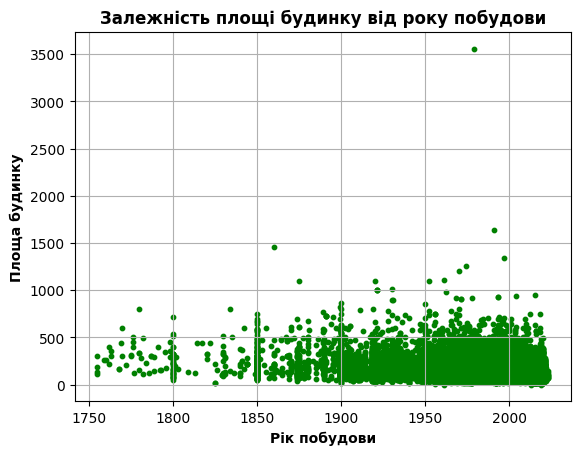

In [ ]:
"""
2. Побудуй scatter plot у Matplotlib, де:
X - construction_year;
Y - house_area;
додай підписи, сітку, маркери ('o').
"""
house_clean = house.copy()
#Будуємо scatter plot
house_clean.plot(x = 'construction_year', y = 'house_area', kind = 'scatter', color = 'g', marker = 'o', s = 10)
#Назва графіку
plt.title('Залежність площі будинку від року побудови', fontweight = 'bold')
#Підпис осі Х
plt.xlabel('Рік побудови', fontweight = 'bold')
#Підпис осі Y
plt.ylabel('Площа будинку', fontweight = 'bold')
#Відображаємо сітку
plt.grid(True)
#Відображаємо готовий графік
plt.show()

Line Chart у Matplotlib

/tmp/ipython-input-1524937156.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_house_area_by_price = house_clean.groupby('price_group')['house_area'].mean()


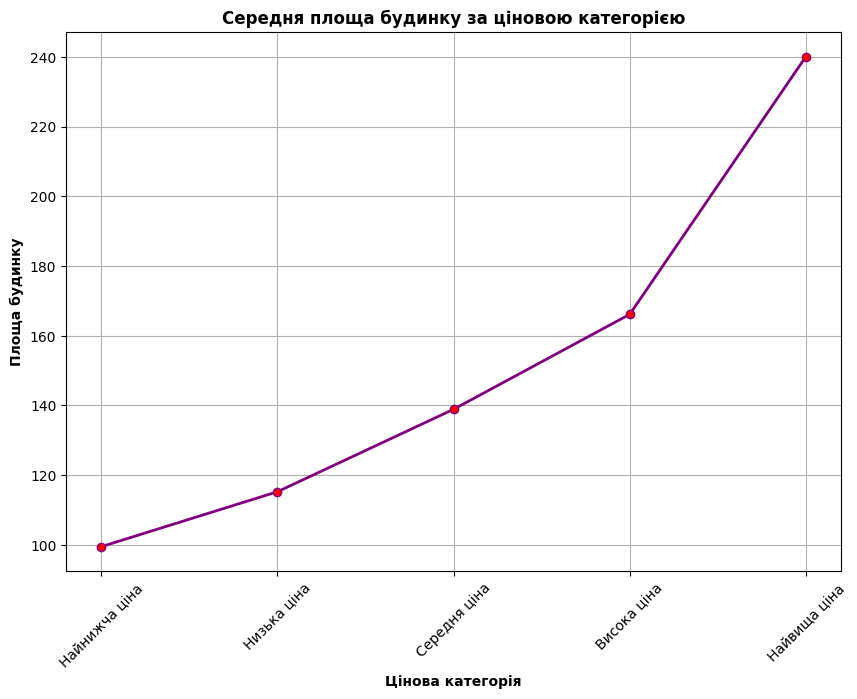

In [ ]:
"""
3. Побудуй line chart у Matplotlib, де:

X - групи ціни (price_group через pd.qcut, 5 рівнів);
Y - середня house_area;
додай маркери, поворот підписів осі X.
"""
house_clean = house.copy()
#Перетворення і очистка price
house_clean['price'] = pd.to_numeric(house_clean['price'], errors='coerce')
house_clean = house_clean.dropna(subset=['price'])

#Виділяємо 5 рівнів ціни
house_clean['price_group'] = pd.qcut(house_clean['price'], 5, labels=['Найнижча ціна', 'Низька ціна', 'Середня ціна', 'Висока ціна', 'Найвища ціна'])
#house_clean['price_group'] = pd.qcut(house_clean['price'], 5, labels=None)

#Перевірка результату
#print(house_clean[['price', 'price_group']])

#Отримуємо середню площу будинків для різних цінових категорій
avg_house_area_by_price = house_clean.groupby('price_group')['house_area'].mean()

#Перевірка результату
#avg_house_area_by_price.head()

#Отримуємо дані для осі Х (price_group)
x_axis = avg_house_area_by_price.index
#Отримуємо дані для осі Y (house_area)
y_axis = avg_house_area_by_price.values
#Змінюємо розмір полотна
plt.figure(figsize=(10, 7))
#Будуємо line chart
plt.plot(x_axis, y_axis, marker = 'o', color = 'purple', linewidth = 2, markerfacecolor = 'red')

#Назва графіку
plt.title('Середня площа будинку за ціновою категорією', fontweight = 'bold')
#Підпис осі Х
plt.xlabel('Цінова категорія', fontweight = 'bold')
#Підпис осі Y
plt.ylabel('Площа будинку', fontweight = 'bold')
#Повертаємо підписи по осі Х
plt.xticks(rotation = 45)
#Відображаємо сітку
plt.grid(True)
#Відображаємо готовий графік
plt.show()

Bar Chart у Matplotlib

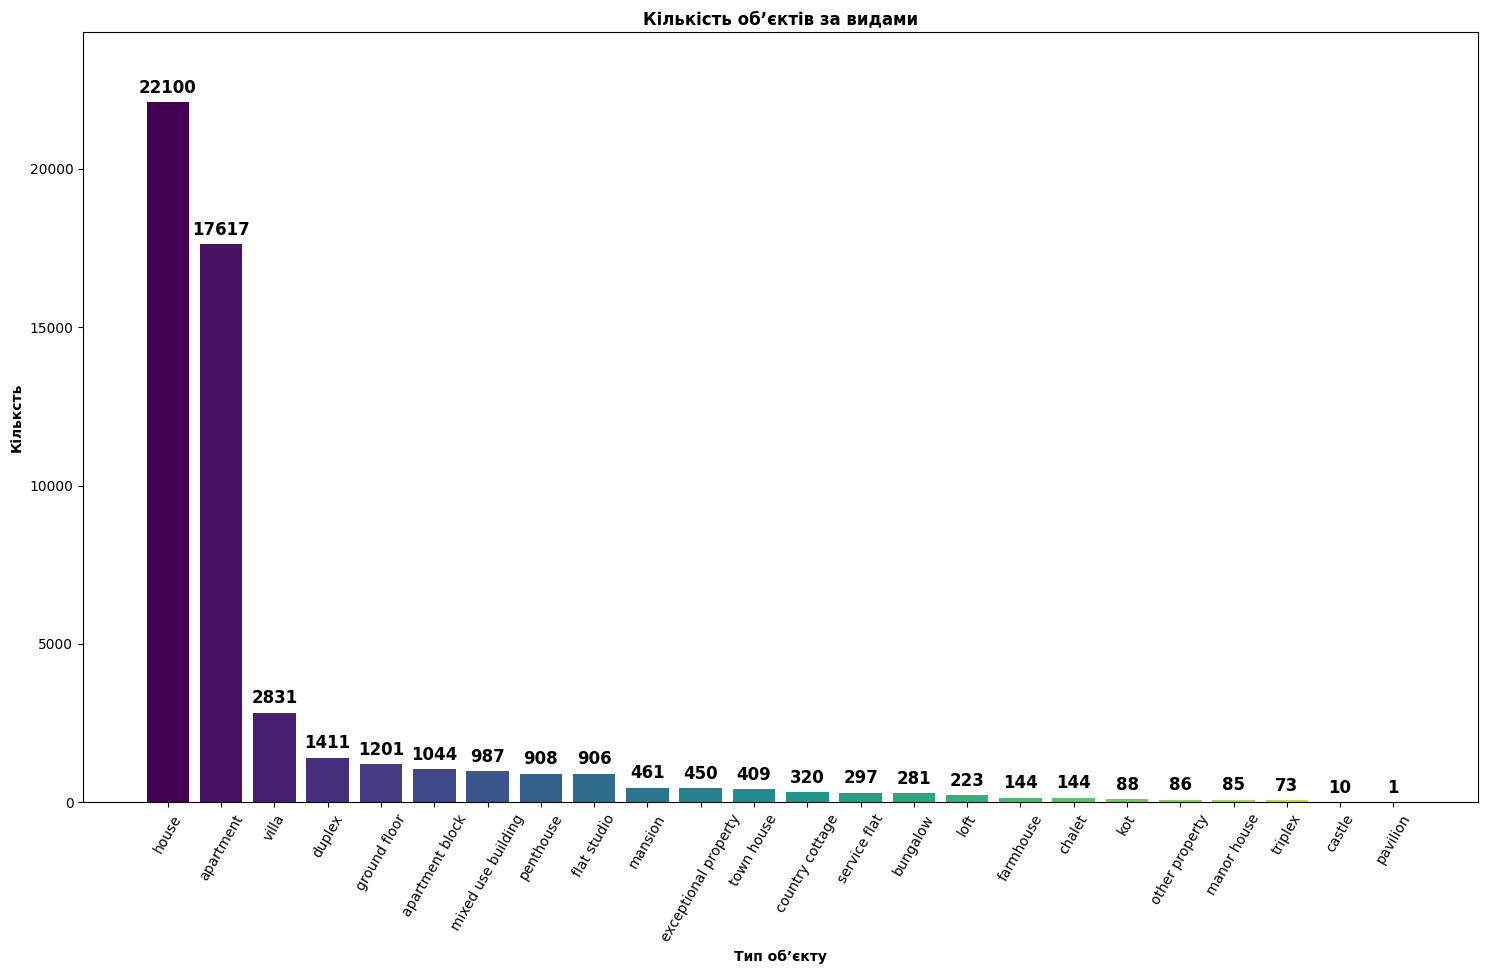

In [ ]:
#4. Побудуй bar chart, який показує кількість об’єктів у розрізі їх виду, з підписами значень.

house_clean = house.copy()
#Рахуємо кількість об'єктів у розрізі їх виду
property_type_count = house_clean['subtype_of_property'].value_counts()
#Перевірка результату
#property_type_count.head()

#Визначаємо категорії для діаграми
categories = property_type_count.index
#Визначаємо висоту стовбчиків (числові дані)
counts = property_type_count.values
#кольори для діаграми
colors = plt.cm.viridis(np.linspace(0, 1, len(categories)))
#Змінюємо розмір полотна
plt.figure(figsize=(18, 10))

#Додаємо простір над стовпчиками, щоб надписи були розміщені коректно
plt.ylim(0, counts.max() * 1.1)
#Будуємо діаграму Bar Chart
plt.bar(categories, counts, color = colors)
#Додавання значень над кожним стовпчиком
for i, count in enumerate(counts):
    plt.text(
        i,                      # x-координата (позиція стовпця)
        count + 300,            # y-координата (трохи вище стовпця)
        str(count),             # текст, що відображається
        ha = 'center',          # горизонтальне вирівнювання: по центру
        fontsize = 12,
        fontweight = 'bold'
    )
#Додаємо назву та підписи осей
plt.title('Кількість обʼєктів за видами', fontweight = 'bold')
plt.xlabel('Тип обʼєкту', fontweight = 'bold')
plt.ylabel('Кільксть', fontweight = 'bold')
#Повертаємо підписи по осі Х
plt.xticks(rotation = 60)
#Відображаємо готовий графік
plt.show()

Lineplot у Seaborn

/tmp/ipython-input-122216771.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_house_area_by_price = house_clean.groupby('price_group')['house_area'].mean()


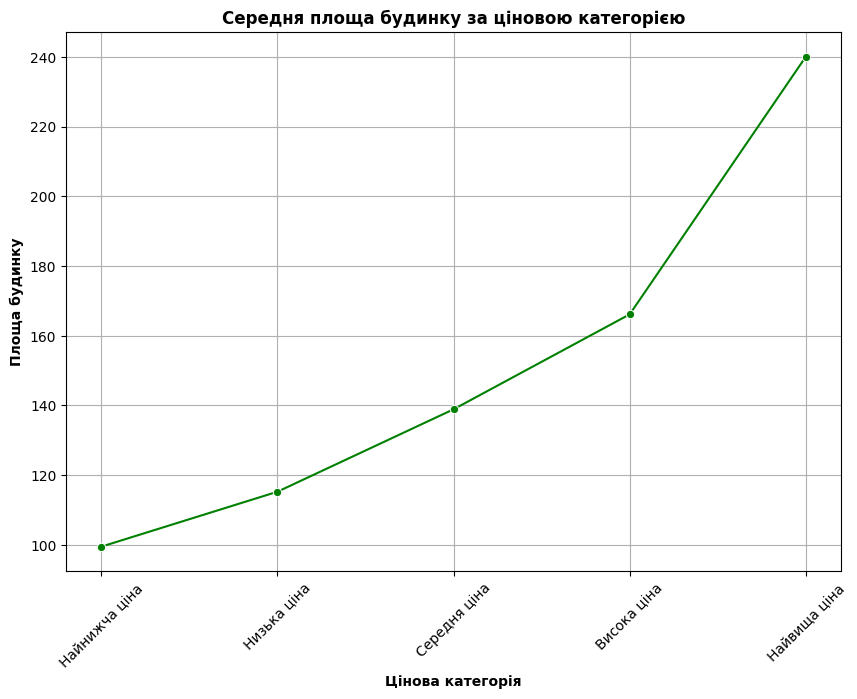

In [ ]:
# 5. Побудуй lineplot у Seaborn, який показує зміну середньої площі area за групами ціни.
house_clean = house.copy()
#Перетворення і очистка price
house_clean['price'] = pd.to_numeric(house_clean['price'], errors='coerce')
house_clean = house_clean.dropna(subset=['price'])

#Виділяємо 5 рівнів ціни
house_clean['price_group'] = pd.qcut(house_clean['price'], 5, labels=['Найнижча ціна', 'Низька ціна', 'Середня ціна', 'Висока ціна', 'Найвища ціна'])
#Отримуємо середню площу будинків для різних цінових категорій
avg_house_area_by_price = house_clean.groupby('price_group')['house_area'].mean()

#Змінюємо розмір полотна
plt.figure(figsize=(10, 7))
#Будуємо lineplot y Seaborn
sns.lineplot(avg_house_area_by_price, color = 'g', marker = 'o')
#Назва графіку
plt.title('Середня площа будинку за ціновою категорією', fontweight = 'bold')
#Підпис осі Х
plt.xlabel('Цінова категорія', fontweight = 'bold')
#Підпис осі Y
plt.ylabel('Площа будинку', fontweight = 'bold')
#Повертаємо підписи по осі Х
plt.xticks(rotation = 45)
#Відображаємо сітку
plt.grid(True)
#Відображаємо готовий графік
plt.show()

Scatterplot у Seaborn

Для графіку scatterplot очищено 25178 рядків


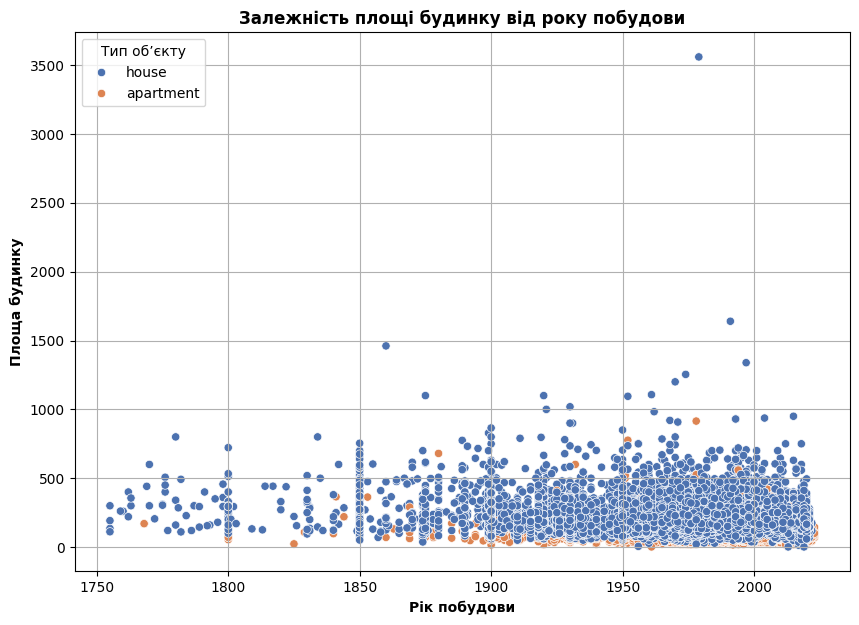

In [ ]:
"""
6. Побудуй scatterplot у Seaborn, де:

X - construction_year;
Y - house_area;
hue - type_of_property (тип обʼєкту)
"""
house_clean = house.copy()
before = len(house_clean)
house_clean = house_clean.dropna(subset=['type_of_property'])
house_clean = house_clean.dropna(subset=['house_area'])
house_clean = house_clean.dropna(subset=['construction_year'])
after = len(house_clean)
print(f'Для графіку scatterplot очищено {before - after} рядків')
#Змінюємо розмір полотна
plt.figure(figsize=(10, 7))
#Будуємо графік
sns.scatterplot(house_clean, x = 'construction_year', y = 'house_area', hue = 'type_of_property', palette='deep')
#Назва графіку
plt.title('Залежність площі будинку від року побудови', fontweight = 'bold')
#Підпис осі Х
plt.xlabel('Рік побудови', fontweight = 'bold')
#Підпис осі Y
plt.ylabel('Площа будинку', fontweight = 'bold')
#Відображаємо сітку
plt.grid(True)
#Назва легенди
plt.legend(title='Тип обʼєкту', loc='upper left')
#Відображаємо готовий графік
plt.show()

Countplot у Seaborn

Для графіку countplot очищено 21369 рядків


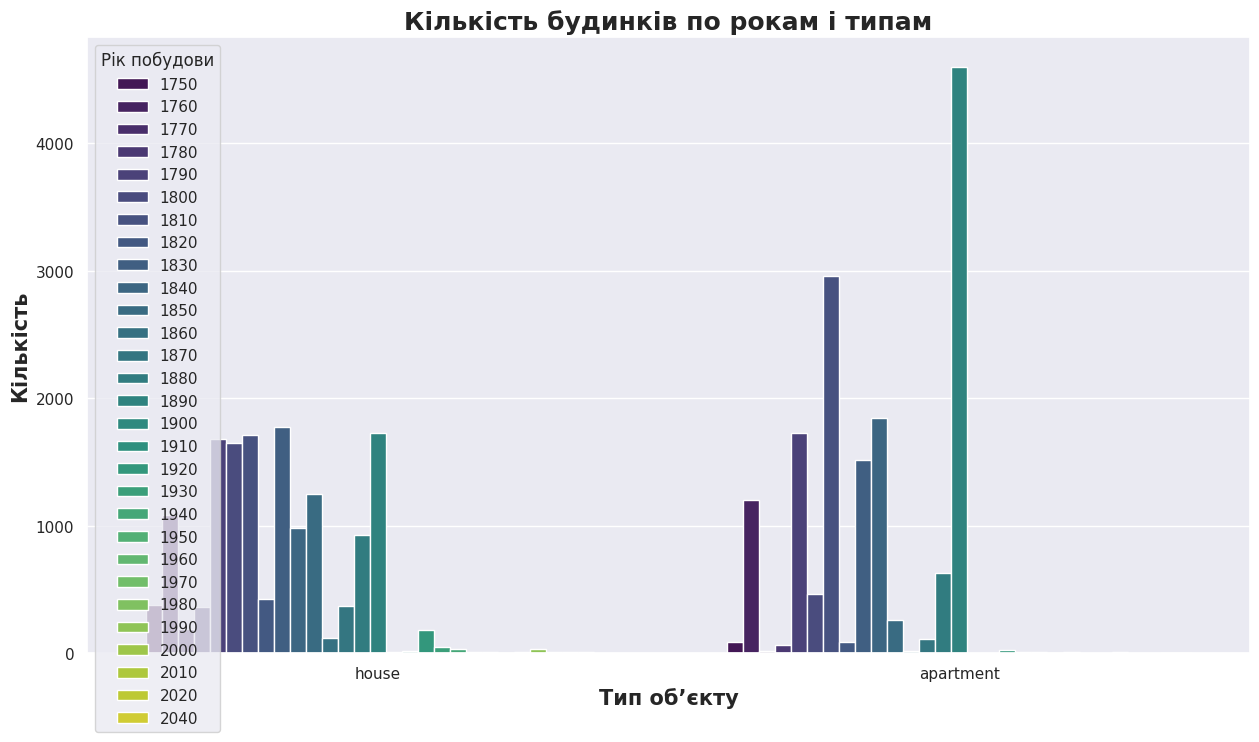

In [ ]:
# 7. Побудуй countplot у Seaborn для type, з hue - construction_year.
house_clean = house.copy()
before = len(house_clean)
house_clean = house_clean.dropna(subset=['type_of_property'])
house_clean = house_clean.dropna(subset=['construction_year'])
after = len(house_clean)
print(f'Для графіку countplot очищено {before - after} рядків')
house_clean['decade'] = ((house_clean['construction_year'] // 10) * 10).astype(int).astype(str)
decades = sorted(list(house_clean['decade'].unique()))
#Змінюємо розмір полотна
plt.figure(figsize=(15, 8))
#Будуємо графік
sns.countplot(house_clean, x = 'type_of_property', hue = 'decade', palette = 'viridis')
#Назва графіку
plt.title('Кількість будинків по рокам і типам', fontweight = 'bold', fontsize=18)
#Підпис осі Х
plt.xlabel('Тип обʼєкту', fontweight = 'bold', fontsize=15)
#Підпис осі Y
plt.ylabel('Кількість', fontweight = 'bold', fontsize=15)
#Назва легенди
plt.legend(title='Рік побудови', loc='upper left', labels = decades)
#Відображаємо готовий графік
plt.show()

Boxplot у Seaborn

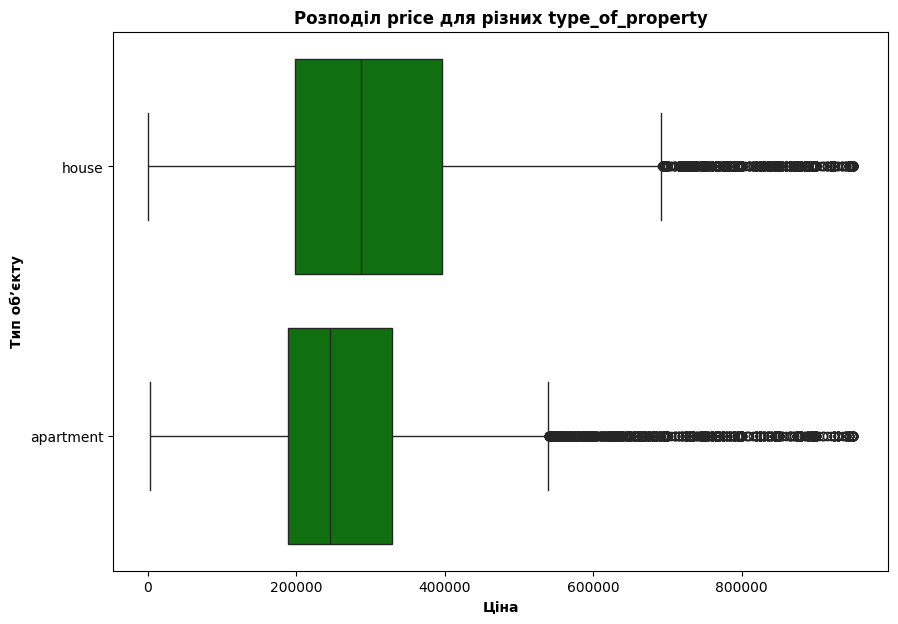

In [ ]:
#8. Побудуй boxplot, який показує розподіл price для різних type_of_property.
house_clean = house.copy()
#Перетворення і очистка price
house_clean['price'] = pd.to_numeric(house_clean['price'], errors='coerce')
house_clean = house_clean.dropna(subset=['price'])
house_clean = house_clean.dropna(subset=['type_of_property'])
#Змінюємо розмір полотна
plt.figure(figsize=(10, 7))
#Будуємо графік
sns.boxplot(house_clean, x = 'price', y= 'type_of_property', color = 'g')
#Назва графіку
plt.title('Розподіл price для різних type_of_property', fontweight = 'bold')
#Підпис осі Х
plt.xlabel('Ціна', fontweight = 'bold')
#Підпис осі Y
plt.ylabel('Тип обʼєкту', fontweight = 'bold')
#Відображаємо готовий графік
plt.show()

Kdeplot y Seaborn

Топ 5 населених пунктів: [8400, 8300, 9000, 8370, 1180]


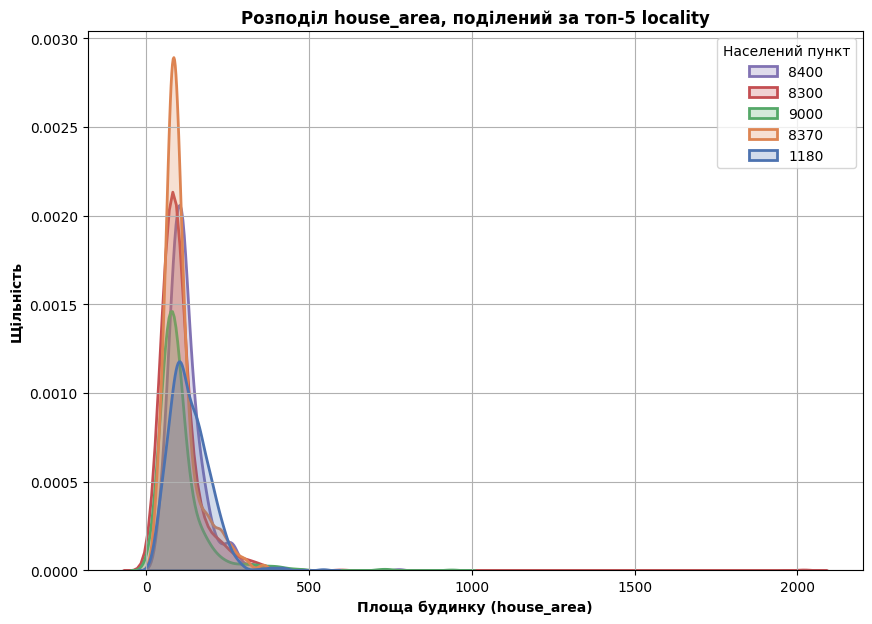

In [ ]:
# 9. Побудуй kdeplot, що відображає розподіл house_area, поділений за топ5 locality.
house_clean = house.copy()
#Визначаємо топ-5 населених пунктів і зберігаємо у список
top_5_localities = house_clean['locality'].value_counts().nlargest(5).index.tolist()
#Перевірка результату
print(f"Топ 5 населених пунктів: {top_5_localities}")
#Фільтруємо записи для цих 5 пунктів з датасету
house_filtered = house_clean[house_clean['locality'].isin(top_5_localities)].copy()
#Видалення рядків з NaN у house_area
house_filtered.dropna(subset=['house_area'], inplace=True)

#Змінюємо розмір полотна
plt.figure(figsize=(10, 7))
#Будуємо графік
sns.kdeplot(house_filtered, x='house_area', hue='locality', palette='deep', fill = True, linewidth = 2)
#Додаємо підписи
plt.title('Розподіл house_area, поділений за топ-5 locality', fontweight = 'bold')
plt.xlabel('Площа будинку (house_area)', fontweight = 'bold')
plt.ylabel('Щільність', fontweight = 'bold')
plt.legend(title='Населений пункт', loc='upper right', labels=top_5_localities)
plt.grid(True)
#Відображаємо готовий графік
plt.show()